# Aprendizaje Automático
#### Segundo cuatrimestre 2026

## Regresión Lineal

#### Bibliografía: 
* Pattern Recognition and Machine Learning, Christopher M. Bishop. Capítulo 3.
* The Elements of Statistical Learning, Trevor Hastie, Robert Tibshirani, Jerome Friedman. Capítulo 3.

Papers:
* Ridge Regression: Biased Estimation for Nonorthogonal Problems, Arthur E. Hoerl and Robert W. Kennard, 1970.
* Regression Shrinkage and Selection via the Lasso, Robert Tibshirani, 1996.
* Regularization and variable selection via the elastic net, Hui Zou y Trevor Hastie, 2005.

### Repaso: Métodos de regularización

Dos formas de motivar los métodos de regularización:
1. **Problemas de multicolinealidad**: Cuando las variables de entrada están altamente correlacionadas, la matriz $\textbf{X}^T \textbf{X}$ es casi singular y su inversa es muy inestable. Esto puede llevar a estimaciones poco confiables de los coeficientes.

1. **Gauss-Markov**: El teorema de Gauss-Markov establece que el estimador de mínimos cuadrados es el mejor estimador lineal insesgado (BLUE). Sin embargo, no garantiza que sea el mejor estimador en términos de varianza. En algunos casos, se pueden encontrar estimadores con menor varianza al introducir un sesgo controlado.

Probablemente veamos Gauss-Markov luego de ver compromiso sesgo-varianza.

### Repaso: Regresión Ridge

1. **Problemas de multicolinealidad**: Cuando las variables de entrada están altamente correlacionadas, la matriz $\textbf{X}^T \textbf{X}$ es casi singular y su inversa es muy inestable. Esto puede llevar a estimaciones poco confiables de los coeficientes.

Podemos plantear de varias formas el problema de la regresión ridge. Una de las más comunes es la siguiente:

$$ \hat{\beta}^{ridge} = \arg \min_{\beta} \{||\textbf{y} - \textbf{X} \beta||^2 + \lambda ||\beta||^2\} $$

$$ \hat{\beta}^{ridge} = \arg \min_{\beta} \{(\textbf{y} - \textbf{X} \beta)^T (\textbf{y} - \textbf{X} \beta) + \lambda \beta^T \beta\} $$

Sin embargo, hay que tener en cuenta que esta expresión solamente es correcta **si los predictores fueron estandarizados**. De manera más explícita, se puede escribir:

$$ \hat{\beta}^{ridge} = \arg \min_{\beta} \{\sum_{i=1}^{N} (y_i - \beta_0 - \sum_{j=1}^{p} x_{ij} \beta_j)^2 + \lambda \sum_{j=1}^{p} \beta_j^2\}$$



### Repaso: Regresión Ridge

A partir de la notación matricial, el problema de la regresión ridge se puede escribir como:

$$ \hat{\beta}^{ridge} = \arg \min_{\beta} \{(\textbf{y} - \textbf{X} \beta)^T (\textbf{y} - \textbf{X} \beta) + \lambda \beta^T \beta\} $$

En términos de una función de costo, esto se puede escribir como:

$$ RSS(\beta, \lambda) = ||\textbf{y} - \textbf{X} \beta||^2 + \lambda ||\beta||^2 $$

Cuya solución es:

$$ \hat{\beta}^{ridge} = (\textbf{X}^T \textbf{X} + \lambda I)^{-1} \textbf{X}^T \textbf{y} $$

### Repaso: Regresión Ridge

¿Por qué aborda el problema de la multicolinealidad?

Usando SVD, podemos reescribir las soluciones de OLS y Ridge como:

* $ \hat{\beta}^{ols} = V D^{-1} U^T y$
* $ \hat{\beta}^{ridge} = V (D^2 + \lambda I)^{-1} D U^T \textbf{y} $

¡La única diferencia es que en lugar de $D^{-1}$ tenemos $(D^2 + \lambda I)^{-1} D$! Ambas son matrices diagonales, en el primer caso cada elemento es $1/d_i$, y en el segundo caso es $d_i/(d_i^2 + \lambda)$. 

* Como tanto $d_i$ como $\lambda$ son no negativos, tenemos que:


$$  (\frac{d_i}{d_i^2 + \lambda}) /  \frac{1}{d_i} = \frac{d_i^2}{d_i^2 + \lambda} \leq 1$$

Que se parece a recortar los valores singulares, pero de una manera más suave.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

/tmp/ipykernel_10222/79807260.py:4: RuntimeWarning: divide by zero encountered in divide
  plt.plot(d_i, 1/d_i, label = 'OLS')


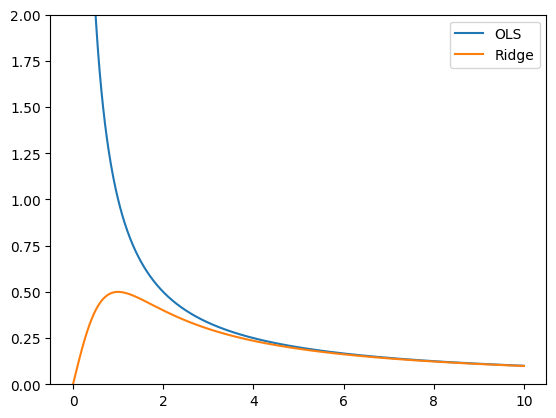

In [3]:
d_i = np.linspace(0.0, 10, 1000)
alpha = 1

plt.plot(d_i, 1/d_i, label = 'OLS')
plt.plot(d_i, d_i/(d_i**2 + alpha), label = 'Ridge')

plt.ylim(0,2)
plt.legend()

### Regresión Lasso

En lugar de penalizar los coeficientes al cuadrado, como en la regresión Ridge, la regresión Lasso penaliza la suma de los valores absolutos de los coeficientes:

$$ \hat{\beta}^{lasso} = \arg \min_{\beta} \{\sum_{i=1}^{N} (y_i - \beta_0 - \sum_{j=1}^{p} x_{ij} \beta_j)^2 + \lambda \sum_{j=1}^{p} |\beta_j|\}$$




### Regresión Lasso

Hay dos formas principales de entrenar el modelo Lasso:

1. ***Coordinate descent***: este es un algoritmo iterativo que optimiza los coeficientes uno a uno, manteniendo los demás fijos. En cada iteración, se actualiza un coeficiente a la vez, minimizando la función de costo con respecto a ese coeficiente mientras se mantienen los otros fijos. Este proceso se repite hasta que los cambios en los coeficientes son pequeños. Es la forma por defecto de entrenar el modelo Lasso en muchas implementaciones, como en `scikit-learn`.

1. ***Least-angle regression (LARS)***: este es un algoritmo que construye el modelo Lasso de manera eficiente. Comienza con todos los coeficientes en cero y agrega variables al modelo de manera secuencial, ajustando los coeficientes a medida que avanza.

### Coordinate descent

Para entender *coordinate descent*, conviene entender antes la función *soft-thresholding*:

$$ S(t, \lambda) = sign(t) (|t| - \lambda)_{+} $$

que es equivalente a $$ S(t, \lambda) = sign(t) \max(0, |t| - \lambda) $$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

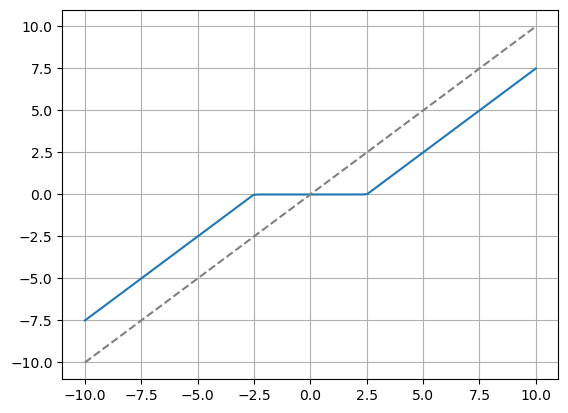

In [2]:
def soft_thresholding(x, lambda_):
    return np.sign(x) * np.maximum(np.abs(x) - lambda_, 0)

lambda_ = 2.5
x = np.linspace(-10, 10, 100)

plt.plot(x, soft_thresholding(x, lambda_))
plt.plot(x, x, linestyle='--', c='gray')
plt.grid()
plt.show()

### Coordinate descent

Para entender *coordinate descent*, conviene entender antes la función *soft-thresholding*:

$$ S(t, \lambda) = sign(t) (|t| - \lambda)_{+} $$

que es equivalente a $$ S(t, \lambda) = sign(t) \max(0, |t| - \lambda) $$

Entonces, lo que hace la función soft-thresholding es "achicar" el valor de $t$ hacia cero, pero si $|t| < \lambda$, lo lleva a cero. Es decir, si el valor absoluto de $t$ es menor que $\lambda$, lo lleva a cero, y si es mayor, lo achica en $\lambda$.

### Coordinate descent

La función a optimizar es $ \hat{\beta}^{lasso} = \arg \min_{\beta} \{\sum_{i=1}^{N} (y_i - \beta_0 - \sum_{j=1}^{p} x_{ij} \beta_j)^2 + \lambda \sum_{j=1}^{p} |\beta_j|\}$. Por simplicidad, vamos a asumir que todos los predictores están estandarizados, junto con la variable de salida, así podemos omitir $\beta_0$. También, separamos las contribuciones de todos los coeficientes $\beta_k$ excepto $\beta_j$:

$$ \hat{\beta}^{lasso} = \arg \min_{\beta} \{\sum_{i=1}^{N} (y_i - \sum_{k \neq j} x_{ik} \beta_k - x_{ij} \beta_j)^2 +  \lambda \sum_{k \neq j} |\beta_k| + \lambda |\beta_j|\}$$

Entonces, 

* Asumimos que ya contamos con una estimación inicial $\tilde{\beta}_k$ de los coeficientes. Ésta puede ser cero, aleatoria, o el resultado de un cálculo previo de mínimos cuadrados o ridge, etc.
* Fijamos todos los coeficientes excepto $\beta_j$

La función de costo queda entonces

$$R( \tilde{\beta}, \beta_j) = \sum_{i=1}^{N} (y_i - \sum_{k \neq j} x_{ik} \tilde{\beta}_k - x_{ij} \beta_j)^2 + \lambda \sum_{k \neq j} |\tilde{\beta}_k| + \lambda |\beta_j| $$

### Coordinate descent

$$R( \tilde{\beta}, \beta_j) = \sum_{i=1}^{N} (y_i - \sum_{k \neq j} x_{ik} \tilde{\beta}_k - x_{ij} \beta_j)^2 + \lambda \sum_{k \neq j} |\tilde{\beta}_k| + \lambda |\beta_j| $$

El término $y_i - \sum_{k \neq j} x_{ik} \tilde{\beta}_k$ es el residuo parcial quitando la contribución de $\beta_j$. Esto es un problema de lasso univariado, que se puede resolver de forma analítica, y cuya solución es:

$$ \hat{\beta}_j = S\left(\frac{1}{N} \sum_{i=1}^{N} x_{ij} (y_i - \sum_{k \neq j} x_{ik} \tilde{\beta}_k), \lambda\right) $$

Para resolver el lasso multivariado, entonces, basta con iterar por cada variable, actualizando su coeficiente según la fórmula anterior, y usando los valores más recientes de los otros coeficientes, hasta convergencia.

### Coordinate descent

Dijimos que la solución de ese problema de Lasso univariado es:

$$ \hat{\beta}_j = S\left(\frac{1}{N} \sum_{i=1}^{N} x_{ij} (y_i - \sum_{k \neq j} x_{ik} \tilde{\beta}_k), \lambda\right) $$

Hagamos la cuenta. 

Para simplificar, vamos a llamar $\tilde{y}_i$ a la predicción de $y_i$ sin la contribución de $\beta_j$. Entonces, la función a optimizar es:

$$R( \tilde{\beta}, \beta_j) = \sum_{i=1}^{N} (y_i - \tilde{y}_i - x_{ij} \beta_j)^2 + \lambda \sum_{k \neq j} |\tilde{\beta}_k| + \lambda |\beta_j| $$

Eventualmente, vamos a buscar el mínimo con respecto a $\beta_j$, por lo que podemos tirar el término $\lambda \sum_{k \neq j} |\tilde{\beta}_k|$ ya que no depende de $\beta_j$. Además, por conveniencia y sin que afecte*, podemos multiplicar por $\frac{1}{2N}$ para que se cancele al derivar.

$$R( \tilde{\beta}, \beta_j) = \frac{1}{2N} \sum_{i=1}^{N} (y_i - \tilde{y}_i - x_{ij} \beta_j)^2 + \lambda |\beta_j| $$

*Notar que cualquier constante multiplicativa que agreguemos en el primer término puede ser eventualmente absorbida en $\lambda$.

### Coordinate descent

$$R( \tilde{\beta}, \beta_j) = \frac{1}{2N} \sum_{i=1}^{N} (y_i - \tilde{y}_i - x_{ij} \beta_j)^2 + \lambda |\beta_j| $$

Expandiendo el cuadrado, se puede reescribir como:

$$R( \tilde{\beta}, \beta_j) = \frac{1}{2N} \sum_{i=1}^{N} (y_i - \tilde{y}_i)^2 - \frac{1}{N} \sum_{i=1}^{N} (y_i - \tilde{y}_i) x_{ij} \beta_j + \frac{1}{2N} \sum_{i=1}^{N} x_{ij}^2 \beta_j^2 + \lambda |\beta_j| $$

El primer término, nuevamente, no depende de $\beta_j$, por lo que podemos descartarlo. Entonces, la función a minimizar es:

$$R( \tilde{\beta}, \beta_j) = \frac{1}{2N} \sum_{i=1}^{N} x_{ij}^2 \beta_j^2 - \frac{1}{N} \sum_{i=1}^{N} (y_i - \tilde{y}_i) x_{ij} \beta_j + \lambda |\beta_j| $$

Como las columnas de $X$ están estandarizadas, $\sum_{i=1}^{N} x_{ij}^2 = N$. También, podemos llamar $a = \frac{1}{N} \sum_{i=1}^{N} (y_i - \tilde{y}_i) x_{ij}$, que es un número fijo. Entonces, la función a minimizar queda:

$$R( \tilde{\beta}, \beta_j) = \frac{1}{2} \beta_j^2 - a \beta_j + \lambda |\beta_j| $$

### Coordinate descent

Entonces, hay que resolver el problema de minimizar la función:

$$R( \tilde{\beta}, \beta_j) = \frac{1}{2} \beta_j^2 - a \beta_j + \lambda |\beta_j| $$

donde $a = \frac{1}{N} \sum_{i=1}^{N} (y_i - \tilde{y}_i) x_{ij}$. 

Seamos un poco desprolijos. Supongamos que podemos derivar.

Si derivamos con respecto a $\beta_j$ e igualamos a cero, obtenemos:

$$ \beta_j - a + \lambda sign(\beta_j) = 0 $$

En primer lugar, notar que si no estuviera el término de penalización, la solución sería $\hat{\beta}_j = a = \frac{1}{N} \sum_{i=1}^{N} (y_i - \tilde{y}_i) x_{ij}$, que es la solución de mínimos cuadrados univariada. 

### Coordinate descent

$$ \beta_j - a + \lambda sign(\beta_j) = 0 $$

Para despejar $\beta_j$, tenemos que considerar casos:

1. Si $\beta_j \gt 0$, entonces $sign(\beta_j) = 1$ y podemos despejar:

$$ \beta_j = \frac{1}{N} \sum_{i=1}^{N}  (y_i - \tilde{y}_i) x_{ij} - \lambda $$

Pero para que se cumpla que $\beta_j \gt 0$, debe ser $ \frac{1}{N}\sum_{i=1}^{N}  (y_i - \tilde{y}_i) x_{ij} \gt \lambda $.

2. Si $\beta_j \lt 0$, entonces $sign(\beta_j) = -1$ y podemos despejar:

$$ \beta_j = \frac{1}{N} \sum_{i=1}^{N}  (y_i - \tilde{y}_i) x_{ij} + \lambda $$

Pero para que se cumpla que $\beta_j \lt 0$, debe ser $ \frac{1}{N} \sum_{i=1}^{N}  (y_i - \tilde{y}_i) x_{ij} \lt -\lambda $.

Notar que en estos dos casos el efecto de $\lambda$ es el mismo; como $\lambda$ es positivo, en el primer caso estamos restando $\lambda$ y en el segundo caso estamos sumando $\lambda$, por lo que estamos achicando el valor absoluto de $\beta_j$ hacia cero. 

Entonces, hasta ahora tenemos que, si podemos derivar:

1. Si $\beta_j \gt 0$, entonces $ \frac{1}{N} \sum_{i=1}^{N}  (y_i - \tilde{y}_i) x_{ij} \gt \lambda $.
1. Si $\beta_j \lt 0$, entonces $ \frac{1}{N} \sum_{i=1}^{N}  (y_i - \tilde{y}_i) x_{ij} \lt -\lambda $.

### Coordinate descent

¿Qué ocurre si $|\frac{1}{N} \sum_{i=1}^{N}  (y_i - \tilde{y}_i) x_{ij}| \leq \lambda$? 

$$R( \tilde{\beta}, \beta_j) = \frac{1}{2} \beta_j^2 - a \beta_j + \lambda |\beta_j| $$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
%matplotlib qt

# Definir el rango para beta
beta = np.linspace(-2.5, 2.5, 400)

# Valores iniciales de los parámetros
a0 = 0
lambda0 = 1.0

# Calcular funciones iniciales
f = 0.5*beta**2 - a0*beta
g = lambda0 * np.abs(beta)
h = f + g

# Crear la figura y el eje
fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)

# Graficar líneas iniciales
line_f, = ax.plot(beta, f, ls = '--', label='f(β) = 1/2 β² - aβ')
line_g, = ax.plot(beta, g, ls = '--', label='g(β) = λ |β|')
line_h, = ax.plot(beta, h, c = 'k', lw = 2, label='f(β) + g(β)')

ax.axhline(0, color='gray', ls='--')


ax.set_xlabel('β')
ax.set_ylabel('Valor')
ax.legend(loc='upper right')
ax.set_ylim(-1,5)


# Ejes de los sliders
ax_a = plt.axes([0.25, 0.15, 0.65, 0.03])  # [izquierda, abajo, ancho, alto]
ax_lambda = plt.axes([0.25, 0.10, 0.65, 0.03])

# Sliders
slider_a = Slider(ax_a, 'a', -5.0, 5.0, valinit=a0)
slider_lambda = Slider(ax_lambda, 'λ', 0.0, 2.0, valinit=lambda0)

# Función de actualización
def update(val):
    a_val = slider_a.val
    lambda_val = slider_lambda.val
    f_new = 0.5*beta**2 - a_val*beta
    g_new = lambda_val * np.abs(beta)
    h_new = f_new + g_new
    line_f.set_ydata(f_new)
    line_g.set_ydata(g_new)
    line_h.set_ydata(h_new)
    fig.canvas.draw_idle()

# Conectar sliders a la función de actualización
slider_a.on_changed(update)
slider_lambda.on_changed(update)

plt.show()


### Coordinate descent

¿Qué ocurre si $|\frac{1}{N} \sum_{i=1}^{N}  (y_i - \tilde{y}_i) x_{ij}| \leq \lambda$? 

$$R( \tilde{\beta}, \beta_j) = \frac{1}{2} \beta_j^2 - a \beta_j + \lambda |\beta_j| $$

En este caso, la solución es $\beta_j = 0$.

Todos los casos quedan cubiertos en:

$$ \hat{\beta}_j = S\left(\frac{1}{N} \sum_{i=1}^{N} x_{ij} (y_i - \sum_{k \neq j} x_{ik} \tilde{\beta}_k), \lambda\right) $$


### Regresión Lasso

¿Por qué Lasso selecciona variables y Ridge no? Para entenderlo, debemos entender la diferencia entre las penalizaciones L1 y L2 y su geometría.

<img src="Figuras/geometría regularización.png" alt="Figura 1" width="400" />

### Regresión Ridge y Lasso

Las formulaciones que hicimos hasta ahora de la regresión Ridge y Lasso se llaman "lagrangianas" y son equivalentes a las siguientes formulaciones:

**Regresión Ridge**

$ \hat{\beta}^{ridge} = \arg \min_{\beta} \{\sum_{i=1}^{N} (y_i - \beta_0 - \sum_{j=1}^{p} x_{ij} \beta_j)^2 \}$ sujeto a  $ \sum_{j=1}^{p} \beta_j^2 \leq t $.

**Regresión Lasso**

$ \hat{\beta}^{lasso} = \arg \min_{\beta} \{\sum_{i=1}^{N} (y_i - \beta_0 - \sum_{j=1}^{p} x_{ij} \beta_j)^2 \}$ sujeto a $ \sum_{j=1}^{p} |\beta_j| \leq t $.

#### **Formulaciones generales**

$$ \hat{\beta} = \arg \min_{\beta} \{\sum_{i=1}^{N} (y_i - \beta_0 - \sum_{j=1}^{p} x_{ij} \beta_j)^2 + \lambda \sum_{j=1}^{p} |\beta_j|^q\} $$

para $q \geq 0$

### Ejercicios

**Ejercicio:** Leer el paper Regression Shrinkage and Selection via the Lasso, Robert Tibshirani, 1996.


**Ejercicio:** Utilizando el dataset de *Prostate Cancer*:
1. Implementar un estimador Lasso. Comparar con los resultados de la Tabla 3.3 del libro Elements of Statistical Learning. ¿Qué nivel de regularización se utilizó?¿Cómo decidirías el nivel de regularización?

**Ejercicio:** Es sabido que la regresión Ridge tiende a devolver coeficientes similares para variables correlacionadas, mientras que Lasso puede dar coeficientes muy diferentes para variables correlacionadas. Vamos a explorar esta propiedad en un escenario muy simple.  

Supongamos que $ n = 2, p = 2, x_{11} = x_{12}, x_{21} = x_{22} $. Además, supongamos que $ y_1 + y_2 = 0 $ y $ x_{11} + x_{21} = 0 $ y $ x_{12} + x_{22} = 0 $, de modo que el estimador de la intersección en un modelo de mínimos cuadrados, regresión Ridge o Lasso es cero: $\hat{\beta}_0 = 0$.

1. Escribir el problema de optimización Ridge en este escenario.  
1. Ver que, en este escenario, las estimaciones de los coeficientes Ridge satisfacen $\hat{\beta}_1 = \hat{\beta}_2$.  

1. Escriba el problema de optimización Lasso en este escenario.  

1. Ver que, en este escenario, los coeficientes de Lasso $\hat{\beta}_1$ y $\hat{\beta}_2$ no son únicos; en otras palabras, hay muchas soluciones posibles para el problema de optimización anterior. Describa esas soluciones.
